# Introduction: Urban Heat Island & Adaptation Strategies

Climate change adaptation focuses on reducing the impacts of climate hazards and increasing the resilience of communities. In urban areas, rising temperatures and heatwaves are a growing concern due to the Urban Heat Island (UHI) effect, where cities become significantly warmer than surrounding rural areas.

This exercise explores satellite observations to analyze urban heat patterns. Students will examine Landsat satellite imagery to identify temperature patterns and discuss potential urban adaptation strategies such as green roofs, urban forests, and reflective surfaces.

In this practical session students will:
- explore satellite data from the Landsat program
- analyze temperature patterns in an urban area
- identify potential urban heat island hotspots
- discuss possible adaptation strategies for cities.


# Landsat Satellite Data

The Landsat program, operated by **NASA and the US Geological Survey (USGS)**, provides one of the longest continuous records of Earth observation. Landsat satellites capture multispectral images of the Earth's surface that can be used to analyze land cover, vegetation, water resources, and urban environments.

For urban climate analysis, Landsat imagery is particularly useful because of its **high spatial resolution (30 m)**, which allows detailed analysis of individual neighborhoods within cities.

**Key characteristics:**
| Feature             | Value    |
| ------------------- | -------- |
| Spatial resolution  | ~30 m    |
| Temporal resolution | ~16 days |
| Coverage            | Global   |
| Data format         | GeoTIFF  |

Typical Landsat scenes contain multiple spectral bands, for example:
- visible light bands
- near-infrared bands
- shortwave infrared bands
- thermal infrared bands

These bands allow researchers to derive indicators such as:
- land surface temperature
- vegetation indices (NDVI)
- built-up area detectio

## Example: Obtaining Landsat 8/9 Collection 2 Level-2 for Berlin area
For this example, we are going to look into Landsat 8/9 Collection 2 Level-2 and focus on the Berlin area.

### Landsat 8/9 Collection 2 Level-2 Data

The **Landsat program**, operated by NASA and the US Geological Survey (USGS), provides long-term satellite observations of Earth's surface. Landsat satellites capture multispectral images that allow analysis of land cover, vegetation, water resources, and urban environments.

For this exercise, we use **Landsat 8/9 Collection 2 Level-2 data**, which provides science-ready products derived from the raw satellite observations.

**Landsat data processing levels**
| Level        | Description                                          |
| ------------ | ---------------------------------------------------- |
| Level-1      | Raw satellite measurements with geometric correction |
| Level-2      | Surface reflectance and surface temperature products |
| Collection 2 | Improved calibration and geolocation accuracy        |

**What Level-2 data contains**

Level-2 products include:

**Surface Reflectance (SR)**
Reflectance values corrected for atmospheric effects.

Example bands:
- SR_B2 – blue
- SR_B3 – green
- SR_B4 – red
- SR_B5 – near-infrared

These bands are commonly used to compute indices such as:
- NDVI (vegetation index)
- land cover classification

### Accessing the data

The dataset can be accessed by going to https://earthexplorer.usgs.gov/ and start by creating an account.

After that, start selectings on this menu: 

<img src="usgs-1.png"  width="200">

There, we select :
- "Use Map" and select the Berlin area by introducing the bounding box coordinates: (13.09, 52.33, 13.76, 52.65)
- Date range 6/01/2025 to 08/31/2025
- Cloud Cover: 0% - 10% and ignore uncertain

On the DataSet Page, navigate to select: 
> Landsat Collection 2 Level-2 -> Landsat 8-9 OLI/TIRS C2 L2

When clicking "Results", it will show multiple scans around the area selected for Berlin. You want to find one that when clicking on *show footprint*, it fully contains the selected area and click "Download All Files Now" on the *Level-2 Surface Temperature Bands* which can be used for:
- Surface temperature analysis
- Urban Heat Island
- Thermal studies

<img src="usgs-3.png"  width="600">

The download will contain 3 .TIF files that should be placed in *Landsat 8-9 C2 L2* folder in order to run the code and the files are:
- "LC09_L2SP_193023_20250819_20250821_02_T1_QA_RADSAT.TIF": Radiometric saturation flags. Helpful quality info, not required for your first heatmap.
- "LC09_L2SP_193023_20250819_20250821_02_T1_ST_ATRAN.TIF" Atmospheric transmittance term used in the LST retrieval. Useful for diagnostics, not required for this exercise.
- "LC09_L2SP_193023_20250819_20250821_02_T1_ST_B10.TIF": The one we need. This is the **Surface Temperature band** (scaled integers). We’ll convert it to Kelvin / Celsius.

*Optional*: go to Select files and chose to download the "QA_PIXEL.tif" file which would be needed to handle weird cold/hot patches.

For the **first step**, we start by inspecting the data inside "LC09_L2SP_193023_20250819_20250821_02_T1_QA_RADSAT.TIF"


In [1]:
import rasterio
from rasterio.plot import show
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt

st_path = "Landsat 8-9 C2 L2/LC09_L2SP_193023_20250819_20250821_02_T1_ST_B10.TIF"

# Inspect data
with rasterio.open(st_path) as src:
    print("CRS:", src.crs)
    print("Resolution (x,y):", src.res)
    print("Bounds:", src.bounds)
    print("Shape (h,w):", (src.height, src.width))
    print("Dtype:", src.dtypes[0])
    print("Nodata:", src.nodata)
    print("Tags (first few):", list(src.tags().items())[:10])

CRS: EPSG:32633
Resolution (x,y): (30.0, 30.0)
Bounds: BoundingBox(left=276285.0, bottom=5762385.0, right=517815.0, top=6006315.0)
Shape (h,w): (8131, 8051)
Dtype: uint16
Nodata: 0.0
Tags (first few): [('AREA_OR_POINT', 'Point')]


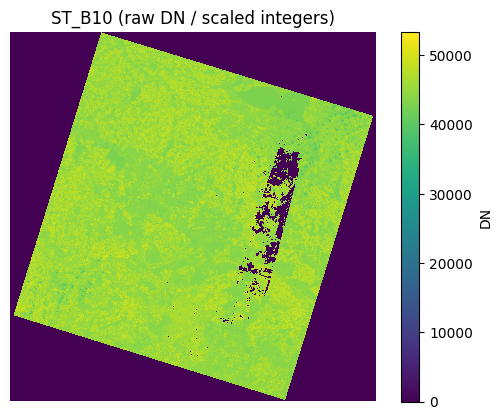

In [2]:
# Quick plot of the full tile
with rasterio.open(st_path) as src:
    st_dn = src.read(1)

plt.figure()
plt.imshow(st_dn, interpolation="nearest")
plt.title("ST_B10 (raw DN / scaled integers)")
plt.axis("off")
plt.colorbar(label="DN")
plt.show()

### Convert ST_B10 to temperature (Kelvin → Celsius)

Common Landsat C2 L2 scaling for surface temperature is:
$$T(K)=DN×0.00341802+149.0$$
$$T(°C)=T(K)−273.15$$

But to be robust, we first try to read scale/offset from tags (if present), and if not, we fall back.

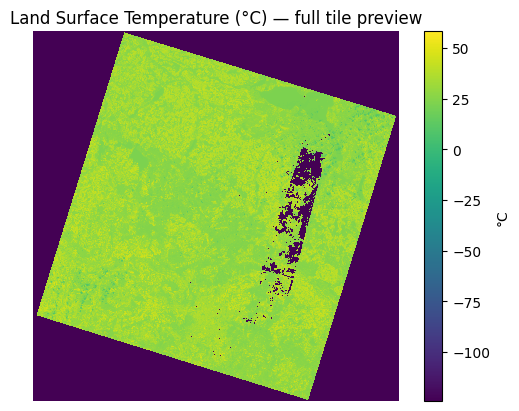

In [3]:
def st_dn_to_celsius(st_dn, scale=None, offset=None):
    # Fallback defaults commonly used for Landsat C2 L2 ST
    if scale is None:
        scale = 0.00341802
    if offset is None:
        offset = 149.0
    temp_k = st_dn * scale + offset
    temp_c = temp_k - 273.15
    return temp_c

with rasterio.open(st_path) as src:
    st_dn = src.read(1).astype("float32")
    tags = src.tags()

# Optional: try to pull scale/offset if tags contain them
scale = None
offset = None
for k, v in tags.items():
    if "scale" in k.lower():
        try: scale = float(v)
        except: pass
    if "offset" in k.lower() or "add" in k.lower():
        try: offset = float(v)
        except: pass

st_c = st_dn_to_celsius(st_dn, scale=scale, offset=offset)

plt.figure()
plt.imshow(st_c, interpolation="nearest")
plt.title("Land Surface Temperature (°C) — full tile preview")
plt.axis("off")
plt.colorbar(label="°C")
plt.show()

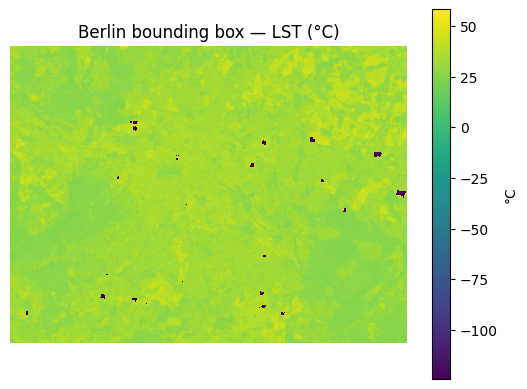

In [4]:
# Crop to Berlin bounding box
from pyproj import Transformer

bbox_lonlat = (13.09, 52.33, 13.76, 52.65)  # (minx, miny, maxx, maxy)

with rasterio.open(st_path) as src:
    raster_crs = src.crs
    transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)

    minx, miny = transformer.transform(bbox_lonlat[0], bbox_lonlat[1])
    maxx, maxy = transformer.transform(bbox_lonlat[2], bbox_lonlat[3])

    window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    st_dn_crop = src.read(1, window=window).astype("float32")

st_c_crop = st_dn_to_celsius(st_dn_crop, scale=scale, offset=offset)

plt.figure()
plt.imshow(st_c_crop, interpolation="nearest")
plt.title("Berlin bounding box — LST (°C)")
plt.axis("off")
plt.colorbar(label="°C")
plt.show()

## Optional: MODIS (Conceptual Introduction)

In addition to Landsat, satellite missions such as MODIS (Moderate Resolution Imaging Spectroradiometer) provide global observations of land surface temperature.

MODIS instruments onboard NASA’s Terra and Aqua satellites provide daily global measurements but at a coarser spatial resolution (~1 km) compared to Landsat.

Because of this difference:
- Landsat is better suited for city-scale analysis
- MODIS is often used for regional or global climate studies

For the Exercise, we are going to stick to Landsat Satellite Data. 

### Exercise 1 — Urban Heat Island Analysis

Students analyze Landsat imagery for a city.

**Task**

Using Landsat surface temperature data:
1. Load the Landsat thermal band dataset.
2. Visualize land surface temperature for the city.
3. Identify areas that appear to have higher temperatures.

**Students should answer**:
- Which areas show the strongest urban heat island effect?
- Do hotter areas correspond to dense built-up areas?
- Where do you observe cooler areas (parks, forests, water bodies)?

### Exercise 2 — Urban Adaptation Design Workshop

Students propose adaptation strategies based on their observations.

**Scenario**

Your city is experiencing increasing summer heatwaves due to climate change.

Using the heat map generated from the Landsat analysis, propose adaptation strategies to reduce heat exposure.

Possible measures include:
- urban tree planting
- green roofs
- reflective building materials
- increased green space
- improved urban water management

**Students should discus**:
- Which neighborhoods should be prioritized?
- Which adaptation strategies are most effective for reducing urban heat?
- What trade-offs might exist between cost, feasibility, and environmental impact?

### Exercise 3 — Case Study: Rotterdam Climate Adaptation

This connects the data analysis to a real-world example.

**Task**

Students examine Rotterdam’s climate adaptation strategy.

Rotterdam has implemented several innovative measures to address flood risk and climate resilience, including:
- water plazas that temporarily store rainwater
- floating buildings
- green roofs
- improved drainage infrastructure

Students discuss:
- Why is Rotterdam particularly vulnerable to flooding?
- What urban design strategies help improve resilience?
- Could similar approaches work in other cities?